In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle
from scipy import stats
from george import kernels
import george
from astropy.io import fits
from functions import *
from glob import glob
from gp_model_params import info
from tqdm import tqdm
import pickle as pkl
from pathlib import Path

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
# Define home directory
home = str(Path.home())

In [155]:
# Define variable type and ID
tp = 'DN'
file_format = '.dat'
id_ = '0002'

In [156]:
# Set directory paths and read period data
tp = 'DN'
direc = home+'/Research_data/Bulge_Variables/%s/'%tp
direc_list = np.sort(glob(direc+'*.fits'))
if not tp == 'DN':
    list_periods = np.genfromtxt(home+'/Research_data/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp), dtype='str')
    n_phs_original = info[tp]['n_phs']

In [157]:
# Define file path for the light curve data
name = home+'/Research_data/Bulge_Variables/%s/OGLE-BLG-%s-%s_multiband_lc.fits' % (tp,tp, id_)
# name = home+'/Research_data/Bulge_Variables/%s/OGLE-BLG-DN-0001.dat'%tp

In [158]:
# If you need to change default model parameters, set them here
# If  not, comment these.
# info[tp]['p0'][1] = 150
# info[tp]['p0'][0] = np.log10(period)
# info[tp]['n_phs'] = 1
# info[tp]['gp_opt_s_param'] = 5
# info[tp]['gp_opt'] = True
# info[tp]['n_phs'] = 6

In [159]:
# Here we read Roman cadences for the Galactic Bulge
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2 = np.load('lc_example/roman_times_longcadence2.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
Roman_sampling_long2_min = min(Roman_sampling_long2)
Roman_sampling_long2 = Roman_sampling_long2 - Roman_sampling_long2_min
Roman_max_short_time = max(Roman_sampling_short)

In [187]:
t_base = Roman_sampling_short
t_base_long = Roman_sampling_long
t_base_long2 = Roman_sampling_long2
t_regular = np.linspace(0, max(Roman_sampling_short), 750000)

In [188]:
# Identify data file and extract period information
i = 0
index = np.where(direc_list == name)[0][i]
path = direc_list[index]
ID = path.split('/')[-1].split('_')[i]
band = 'I'
if not tp == 'DN':
    period = float(list_periods[list_periods[:, 0] == ID][0][1])
else:
    period = np.nan

In [189]:
# Read the light curve data
period, df_ = read_fits(path, period=period, tp=tp)
try:
    df = df_[df_.band == band]
    print(df_.groupby('band').size())
except AttributeError:
    print('Error: %s band does not exist. Skipping...' % band)

# Check if sufficient data points exist
if len(df) < 10:
    print('Error: Found less than 10 data points. Skipping...')

df = df.reset_index(drop=True)

band
H0       1
I     9770
dtype: int64


In [190]:
df = df_[df_.band == 'I']

(400.0, 600.0)

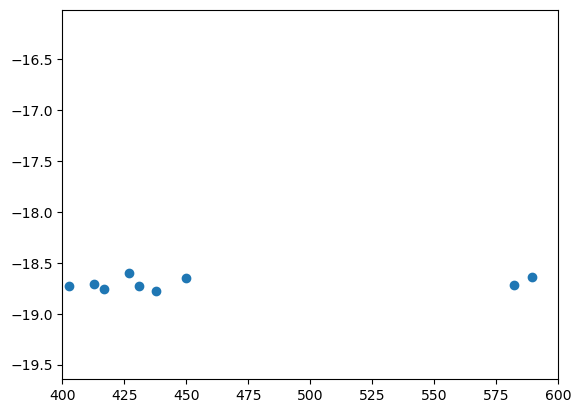

In [191]:
plt.scatter(df.t,
            -1*df.m)
plt.xlim(400, 600)


In [192]:
inds = np.where(np.diff(df.t.values)>50)[0]

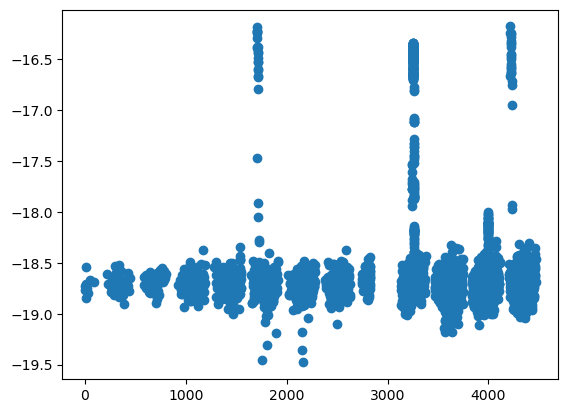

In [193]:
plt.scatter(df.t, -1*df.m)

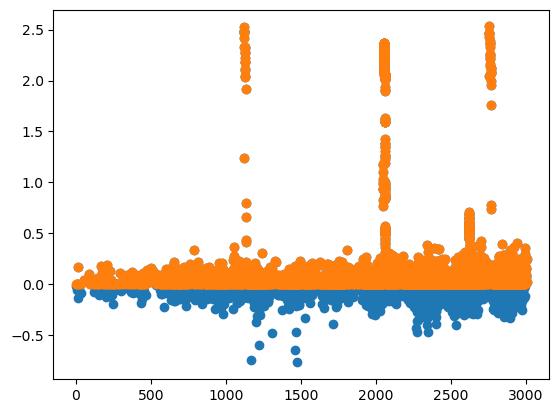

In [222]:
plt.scatter(df.t, -1*mags+baseline_mag)
plt.scatter(df.t, -1*y_mags)


# plt.xlim(3225, 3280)

In [223]:
# Normalize time axis
if np.min(df.t) > 0:
    df.t = df.t - np.min(df.t)

In [224]:
# Reduce the gaps and extend data if necessary
if tp not in ['DN','CV']:
    if (np.max(df.t))<1713:
        df = add_last_point(df, period)
    df_modified = gap_reducer(df, period, info[tp])
    if (np.max(df_modified.t))<1713 and np.isinf(info[tp]['n_phs']):
        df_modified = extend_baseline(df_modified, period)
    while np.max(df_modified.t.values)<1713+period:
        len_0 = np.diff(df_modified.t.values)
        df_modified = gap_reducer(df_modified, period, info[tp])
        len_1 = np.diff(df_modified.t.values)
        if np.max(df_modified.t.values)>1713:
            break
        if np.sum(len_0>50) == np.sum(len_1>50):
            break
else:
    t_min = np.min(np.diff(df.t.values))
    for i, ind in enumerate(inds):
        time_gap = df.t[ind+1]-df.t[ind]+t_min
        df.loc[df.index[ind+1]:, 't'] -= time_gap
    n_lc = int(max(df.t)//1713.)
    df_modified = df#[df.t<1714]
    

In [228]:
mags = df_modified.m.values
threshold_mag = -0.01 #np.percentile(y_binned, 10)
baseline_mag = np.percentile(mags, 50) # your quiescent magnitude
# y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))

y_mags = mags.copy()
mask = (mags > threshold_mag+baseline_mag)

y_mags[mask] = np.ones_like(y_mags[mask]) * baseline_mag #+ np.random.normal(0, 0.001, size=len(y_sim[mask]))

y_mags = y_mags - np.median(y_mags)
df_modified.loc[:, 'm'] = y_mags

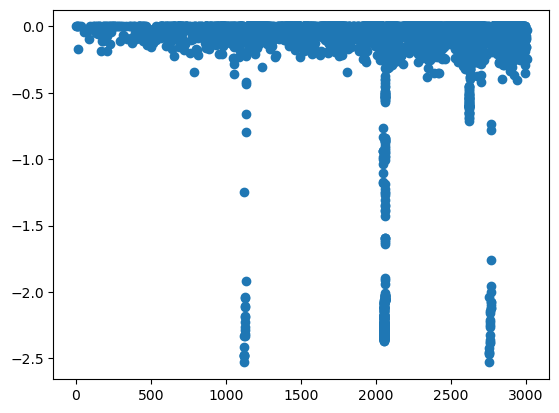

In [229]:
plt.scatter(df_modified.t, df_modified.m)

In [230]:
# Prepare input for Gaussian Process
gp = prep_gp(info[tp], period)

x, y, e = prep_input(df_modified, 
                     tp, 
                     period, 
                     info[tp], 
                     Roman_max_short_time)# x, y, e are either 
                                    # the full lc or an intrval 
                                    # of n phases of them conducted 
                                    # by repeating a folded phase n times

In [216]:
# Bin the data if necessary
if not np.isinf(info[tp]['n_phs']):
    if len(x)/info[tp]['n_phs']>150:
        if info[tp]['fit_binned']==False:
            info[tp]['fit_binned'] = True
        tot_ideal_len = info[tp]['n_phs']*info[tp]['count_per_bins']
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        info[tp]['fit_binned'] = False
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=np.nan)
else:
    if len(x)>1500:
        info[tp]['fit_binned'] = True
        tot_ideal_len = 1500
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                      y, 
                                                                      e, 
                                                                      info[tp], 
                                                                      n_bins=np.nan)
    

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [217]:
x_binned = x_binned[~np.isnan(e_binned)]
y_binned = y_binned[~np.isnan(e_binned)]
e_binned = e_binned[~np.isnan(e_binned)]
# ind = y_binned<np.percentile(y_binned, 50)
# x_binned = x_binned[ind]
# y_binned = y_binned[ind]
# e_binned = e_binned[ind]

In [183]:
baseline_mag

np.float64(-0.002797297297295387)

In [184]:
threshold_mag = -0.01 #np.percentile(y_binned, 10)
baseline_mag = np.percentile(y_binned, 50) # your quiescent magnitude
# y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
y_sim = y_binned.copy()
mask = (y_binned > threshold_mag)

y_sim[mask] = np.ones_like(y_sim[mask]) * baseline_mag #+ np.random.normal(0, 0.001, size=len(y_sim[mask]))

y_sim = y_sim - np.median(y_sim)

(-0.01, 0.1)

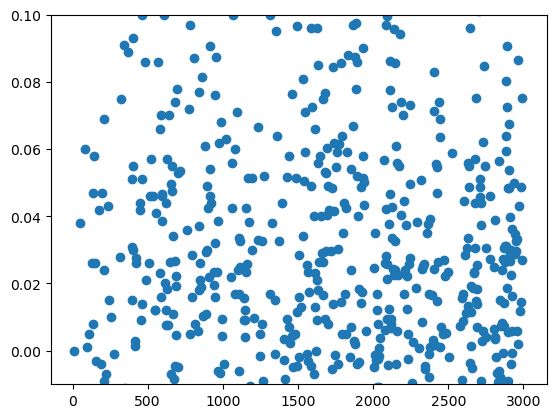

In [219]:
# plt.scatter(x_binned, 
#             -1*y_sim)

plt.scatter(x_binned, 
            -1*y_binned)
# plt.xlim(400, 600)

plt.ylim(-0.01,0.1)

In [143]:
# Fit Gaussian Process to binned data
gp = fit_gp(x_binned, y_sim, e_binned, info[tp], gp)

In [144]:
y_regular = gp.predict(y_sim, t_regular, return_var=True)[0]

In [145]:
# # Fitting the gp model
# y_median = np.median(y)
# max_time_regular = 2000
# period = np.nan
# (df_roman, 
# time_sampling_regular_final,
#  gp_y_regular_final,
#  gp_std_regular_final,
#   gp_y_regular_fit,\
#    gp_std_regular_fit) = predict_gp(gp, 
#                                     y_sim, 
#                                     y_median, 
#                                     regular_sampling_fit, 
#                                     Roman_sampling_short,
#                                     Roman_sampling_long, 
#                                     info[tp], 
#                                     period,
#                                     max_time_regular
#                                     )

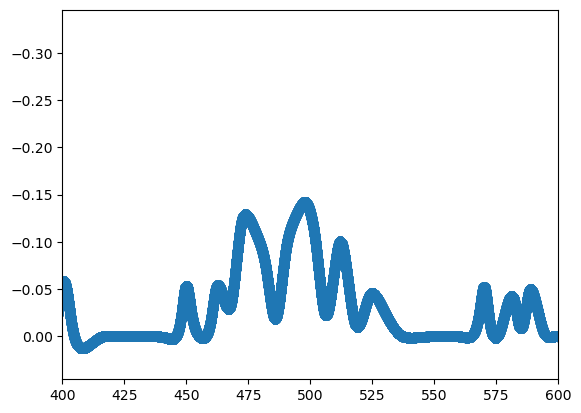

In [153]:
plt.scatter(t_regular,
           y_regular)
# plt.scatter(x_binned, y_sim, color='g')

plt.xlim(400, 600)
plt.gca().invert_yaxis()

In [147]:
threshold_mag = -0.01 #np.percentile(gp_y_regular_final, 10)
baseline_mag = np.percentile(y_regular, 50) # your quiescent magnitude
# y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
y_sim = y_regular.copy()
mask = (y_regular > threshold_mag)

y_sim[mask] = np.ones_like(y_sim[mask]) * baseline_mag #+ np.random.normal(0, 0.001, size=len(y_sim[mask]))

y_sim = y_sim - np.median(y_sim)

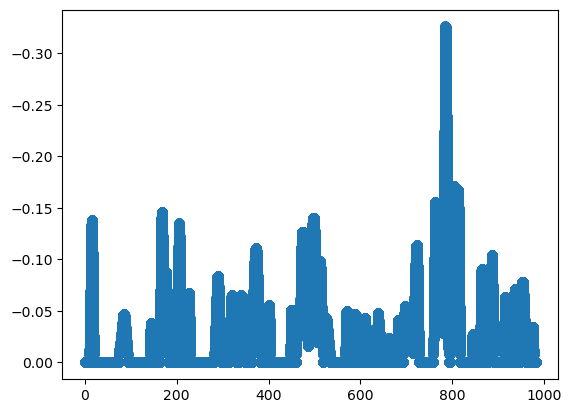

In [148]:
plt.scatter(t_regular,
           y_sim)
# plt.scatter(x_binned, y_sim, color='g')

# plt.xlim(380, 450)
plt.gca().invert_yaxis()

In [149]:
interp_baseline = interp1d(t_regular, y_sim, kind='linear', bounds_error=False, fill_value=np.nan)
y_base = interp_baseline(t_base)
y_base_long = interp_baseline(t_base_long)
y_base_long2 = interp_baseline(t_base_long2)

(600.0, 800.0)

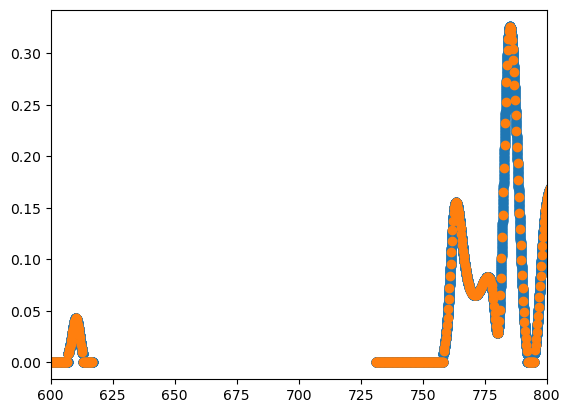

In [152]:
plt.scatter(t_base,
            -1*y_base)
plt.scatter(t_base_long,
            -1*y_base_long)
plt.xlim(600, 800)

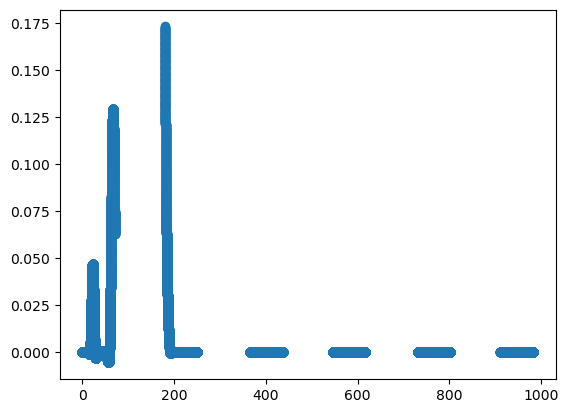

In [29]:
plt.scatter(df_roman['t_short'],
            -1*df_roman['m_short'])
# plt.xlim(0, 100)

In [34]:
# info[tp]['gp_opt_s_param']=3

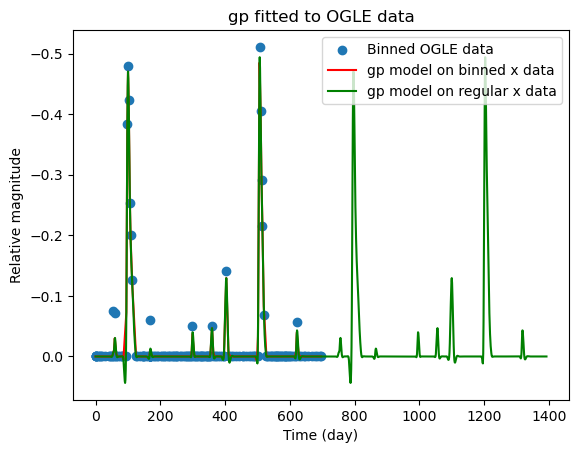

In [35]:
# Predict on the binned x data to check the l2 distance 
# between the fit and the binned y data
gp_y_binned_fit, cov_tmp = gp.predict(y_sim, x_binned)
plt.scatter(x_binned, y_sim, label='Binned OGLE data')
plt.plot(x_binned, gp_y_binned_fit, 'r', label='gp model on binned x data')
plt.plot(time_sampling_regular_final, gp_y_regular_final,'g', label='gp model on regular x data')
plt.legend()
plt.title('gp fitted to OGLE data')
plt.xlabel('Time (day)')
plt.ylabel('Relative magnitude')
plt.gca().invert_yaxis()
# plt.xlim(0, 250)

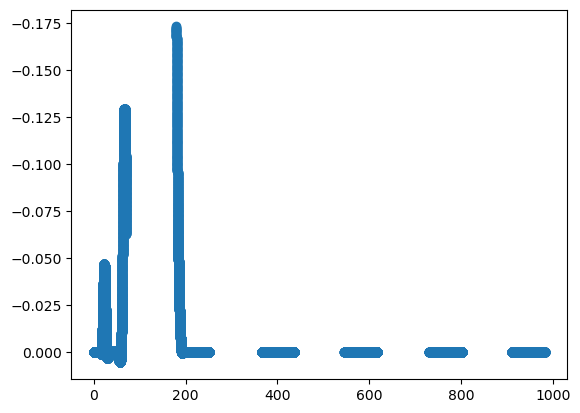

In [36]:
plt.scatter(df_roman['t_short'],
df_roman['m_short'])
plt.gca().invert_yaxis()
# plt.xlim(900, 1000)

In [37]:
df_roman['t_short']

array([0.00000000e+00, 8.40277784e-03, 1.68055557e-02, ...,
       9.81978264e+02, 9.81986667e+02, 9.81995069e+02], shape=(50700,))

In [38]:
# Calculate metrics for evaluation

# L2 distance between y_binned and gp fit on x_binned.
l2_binned = (np.nanmean((y_binned-(gp_y_binned_fit))**2))

# Ratio of std of y_binned over std of gp fit on x_binned.
std_binned = np.std(y_binned)/np.std(gp_y_binned_fit)

# L2 distance between gp fit on x_binned and gp fit on regular sampling.
l2_regular = l2_distance(x_binned, gp_y_binned_fit, regular_sampling_fit, gp_y_regular_fit)

# L2 distance of the different portions of 1/3 of the light curve
part1 = np.nanmean((y_binned[:int(len(y_binned)/3)]-
                      (gp_y_binned_fit[:int(len(y_binned)/3)]))**2)
part2 = np.nanmean((y_binned[int(len(y_binned)/3):2*int(len(y_binned)/3)]-
                      (gp_y_binned_fit[int(len(y_binned)/3):2*int(len(y_binned)/3)]))**2)
part3 = np.nanmean((y_binned[2*int(len(y_binned)/3):int(len(y_binned))]-
                      (gp_y_binned_fit[2*int(len(y_binned)/3):int(len(y_binned))]))**2)

metrics = np.array([std_binned, 
                    l2_regular,
                    l2_binned,
                    part1,
                    part2,
                    part3])
print('std of binned fit, l2 metric of the regular fit and'
      ' the l2 metric of the binned fit are = %.9f, %.9f, %.9f'%
      (std_binned, 
       l2_regular,
       l2_binned,))
print('mean metric of first, second, and third portion of the lc = %.9f, %.9f, %.9f'%
      (part1, 
       part2, 
       part3))

std of binned fit, l2 metric of the regular fit and the l2 metric of the binned fit are = 1.086253597, 0.206556592, 0.000868753
mean metric of first, second, and third portion of the lc = 0.001144631, 0.000684072, 0.000779101


In [39]:
# this is for periodic variability
if not np.isnan(period):
    fig, ax = plt.subplots(2, 2, figsize=(10,5))
    ax[0, 0].scatter(time_sampling_regular_final, 
                  gp_y_regular_final+y_median,
                  label='Extended with regular sampling')
    ax[0, 1].scatter((time_sampling_regular_final/period)%1, 
                  gp_y_regular_final+y_median)
    # 
    # plt.scatter(regular_sampling_fit, gp_y_regular_fit)
    ax[0, 0].scatter(x_binned, y_binned+y_median, color='r', label='Binned data')
    ax[1, 1].scatter((df_roman.t/period)%1, df_roman.m+y_median, color='g')
    ax[1, 0].scatter(df_roman.t, df_roman.m+y_median, color='g')
    # ax[0].set_xlim(1,3)
    
    ax[1, 0].set_xlabel('Time (days)')
    ax[1, 1].set_xlabel('Phase')
    ax[0, 0].set_ylabel('Magnitude')
    ax[1, 0].set_ylabel('Magnitude')
    ax[0, 0].legend()

In [40]:
# Evaluate the fit
# Try other number of phases if the first fit did not pass the criteria
n_phs_original = np.inf
if not np.isinf(n_phs_original):
    phases = [n_phs_original-3, 
              n_phs_original-2, 
              n_phs_original-1, 
              n_phs_original+1, 
              n_phs_original+2,
             n_phs_original+3]
    best_phs = evaluate_fit(df_modified, 
                            tp, 
                            period, 
                            phases, 
                            metrics, 
                            info[tp], 
                            verbose=True)
else:
    phases =[n_phs_original]
    best_phs = np.inf
    if len(find_valid_rows(np.array([metrics]), 
           threshold=info[tp]['metric_threshold'],
           threshold_std=info[tp]['metric_threshold_std'],
           level = 3))==1:
        print('No need for evaluation. Passed.')


In [41]:
if np.isnan(best_phs):
    flags[i] = 1
    print('Error: Evaluation failed (no good phase!). Skipping...')
elif np.isinf(best_phs):
    print('Passed')
    pass
else:
    info[tp]['n_phs'] = best_phs
    (df_roman, 
       time_sampling_regular_final,
       gp_y_regular_final,
       gp_std_regular_final,
       regular_sampling_fit,
       gp_y_regular_fit,
       gp_std_regular_fit,
       gp_y_binned_fit, 
       y_median,
       metrics,
       data) = run_all(df_modified, tp, period, info[tp], verbose=False)

    if len(find_valid_rows(np.array([metrics]), 
                           threshold=info[tp]['metric_threshold'],
                           threshold_std=info[tp]['metric_threshold_std']))==0:
        flags[i] = 1
        print('Error: Evaluation best_phs fit failed. Skipping...')


Passed


In [42]:
# this is for periodic variability
if not np.isnan(period):
    fig, axs = plt.subplots(1,2, figsize=(10, 5))
    if np.isinf(info[tp]['n_phs']):
        tmp_period = period
    else:
        tmp_period = 1/info[tp]['n_phs']
        
    axs[0].errorbar(x, y, yerr=e, fmt = '.', ms = 10, label = 'OGLE data')
    
    # axs[0].plot(bin_middles, bin_means, '.', zorder=11, label = 'Binned OGLE data')
    axs[0].plot(regular_sampling_fit, gp_y_regular_fit+y_median, linewidth = 4, label='GP model', zorder=11)
    # axs[0].set_xlabel('%i Phases'%info[tp]['n_phs'], size=15)
    axs[0].set_ylabel('Magnitude', size=15)
    axs
    axs[0].legend()
    axs[0].invert_yaxis()
    
    axs[1].errorbar((x/tmp_period)%1, y,yerr=e, fmt = '.', ms = 10, label = 'Folded OGLE data')
    
    # axs[1].plot((bin_middles/tmp_period)%1, bin_means, '.', zorder=11, label='Binned OGLE data')
    axs[1].plot((regular_sampling_fit/tmp_period)%1, 
                 gp_y_regular_fit+y_median,
                '.', 
                linewidth = 4, 
                label='Folded GP model', 
                zorder=11)
    axs[1].set_xlabel('One Phase', size=15)
    axs[1].set_ylabel('Magnitude', size=15)
    axs[1].legend()
    axs[1].invert_yaxis()